In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [20]:
base_dir = os.getcwd()
loan_data_dir = os.path.join(base_dir, 'Ex1', 'Loan Modelling Thera Bank.csv')
customer_data_dir = os.path.join(base_dir, 'Ex1', 'customer_data.csv')

In [22]:
df_loan = pd.read_csv(loan_data_dir)

In [23]:
df_loan.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [24]:
df_loan.keys()

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='str')

In [ ]:
df_loan.columns
# giống hệt keys

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='str')

In [26]:
df_loan.index

RangeIndex(start=0, stop=5000, step=1)

In [ ]:
df_loan.info()
# cho biết các cột số lượng các ô khác null của từng cột và kiểu dữ liệu

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [29]:
df_loan.describe()
# đối với kiểu dữ liệu số học thì sẽ cho biết 1 số thuộc tính thống kê
# 25% là giá trị mà 25% lượng dữ liệu của cột bé hơn hoặc bằng...
# đới với kiểu dữ liệu object thì sẽ hiển thị count, unique, top, fre

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


- pairplot cho thấy sự tương quan giữa các thuộc tính nếu đầu vào là n cột thì đầu ra là n*n biểu đồ
- nếu 1 thuộc tính tự tương quan với chính nó thì 1 biểu đồ kde được vẽ ra thể hiện hàm mật độ xác suất (có thể thấy tuổi có 2 hàm mật độ khác màu nhau tượng trưng cho 2 giá trị khác nhau của personal loan). ta có thể quan sát được là đường chéo chính của ma trận đồ thị là các ma trận kde
- Tham số hue để đánh dấu các biến của biểu đồ các biến sẽ được tô màu khác với các đặc tính khác
- Ta có thể thấy cột personal loan chỉ có giá trị là 0 hoặc 1 được đánh bằng 2 màu khác nhau
- Biểu đồ tương quan của 2 đặc tính có thể hiểu là 1 đặc tính làm trục tung còn 1 đặc tính làm trục hoành, mỗi điểm trong biểu đồ là instance, mỗi điểm có thể có màu khác nhau nếu ta điển tham số hue

In [32]:
df_loan['Personal Loan'].unique()

array([0, 1])

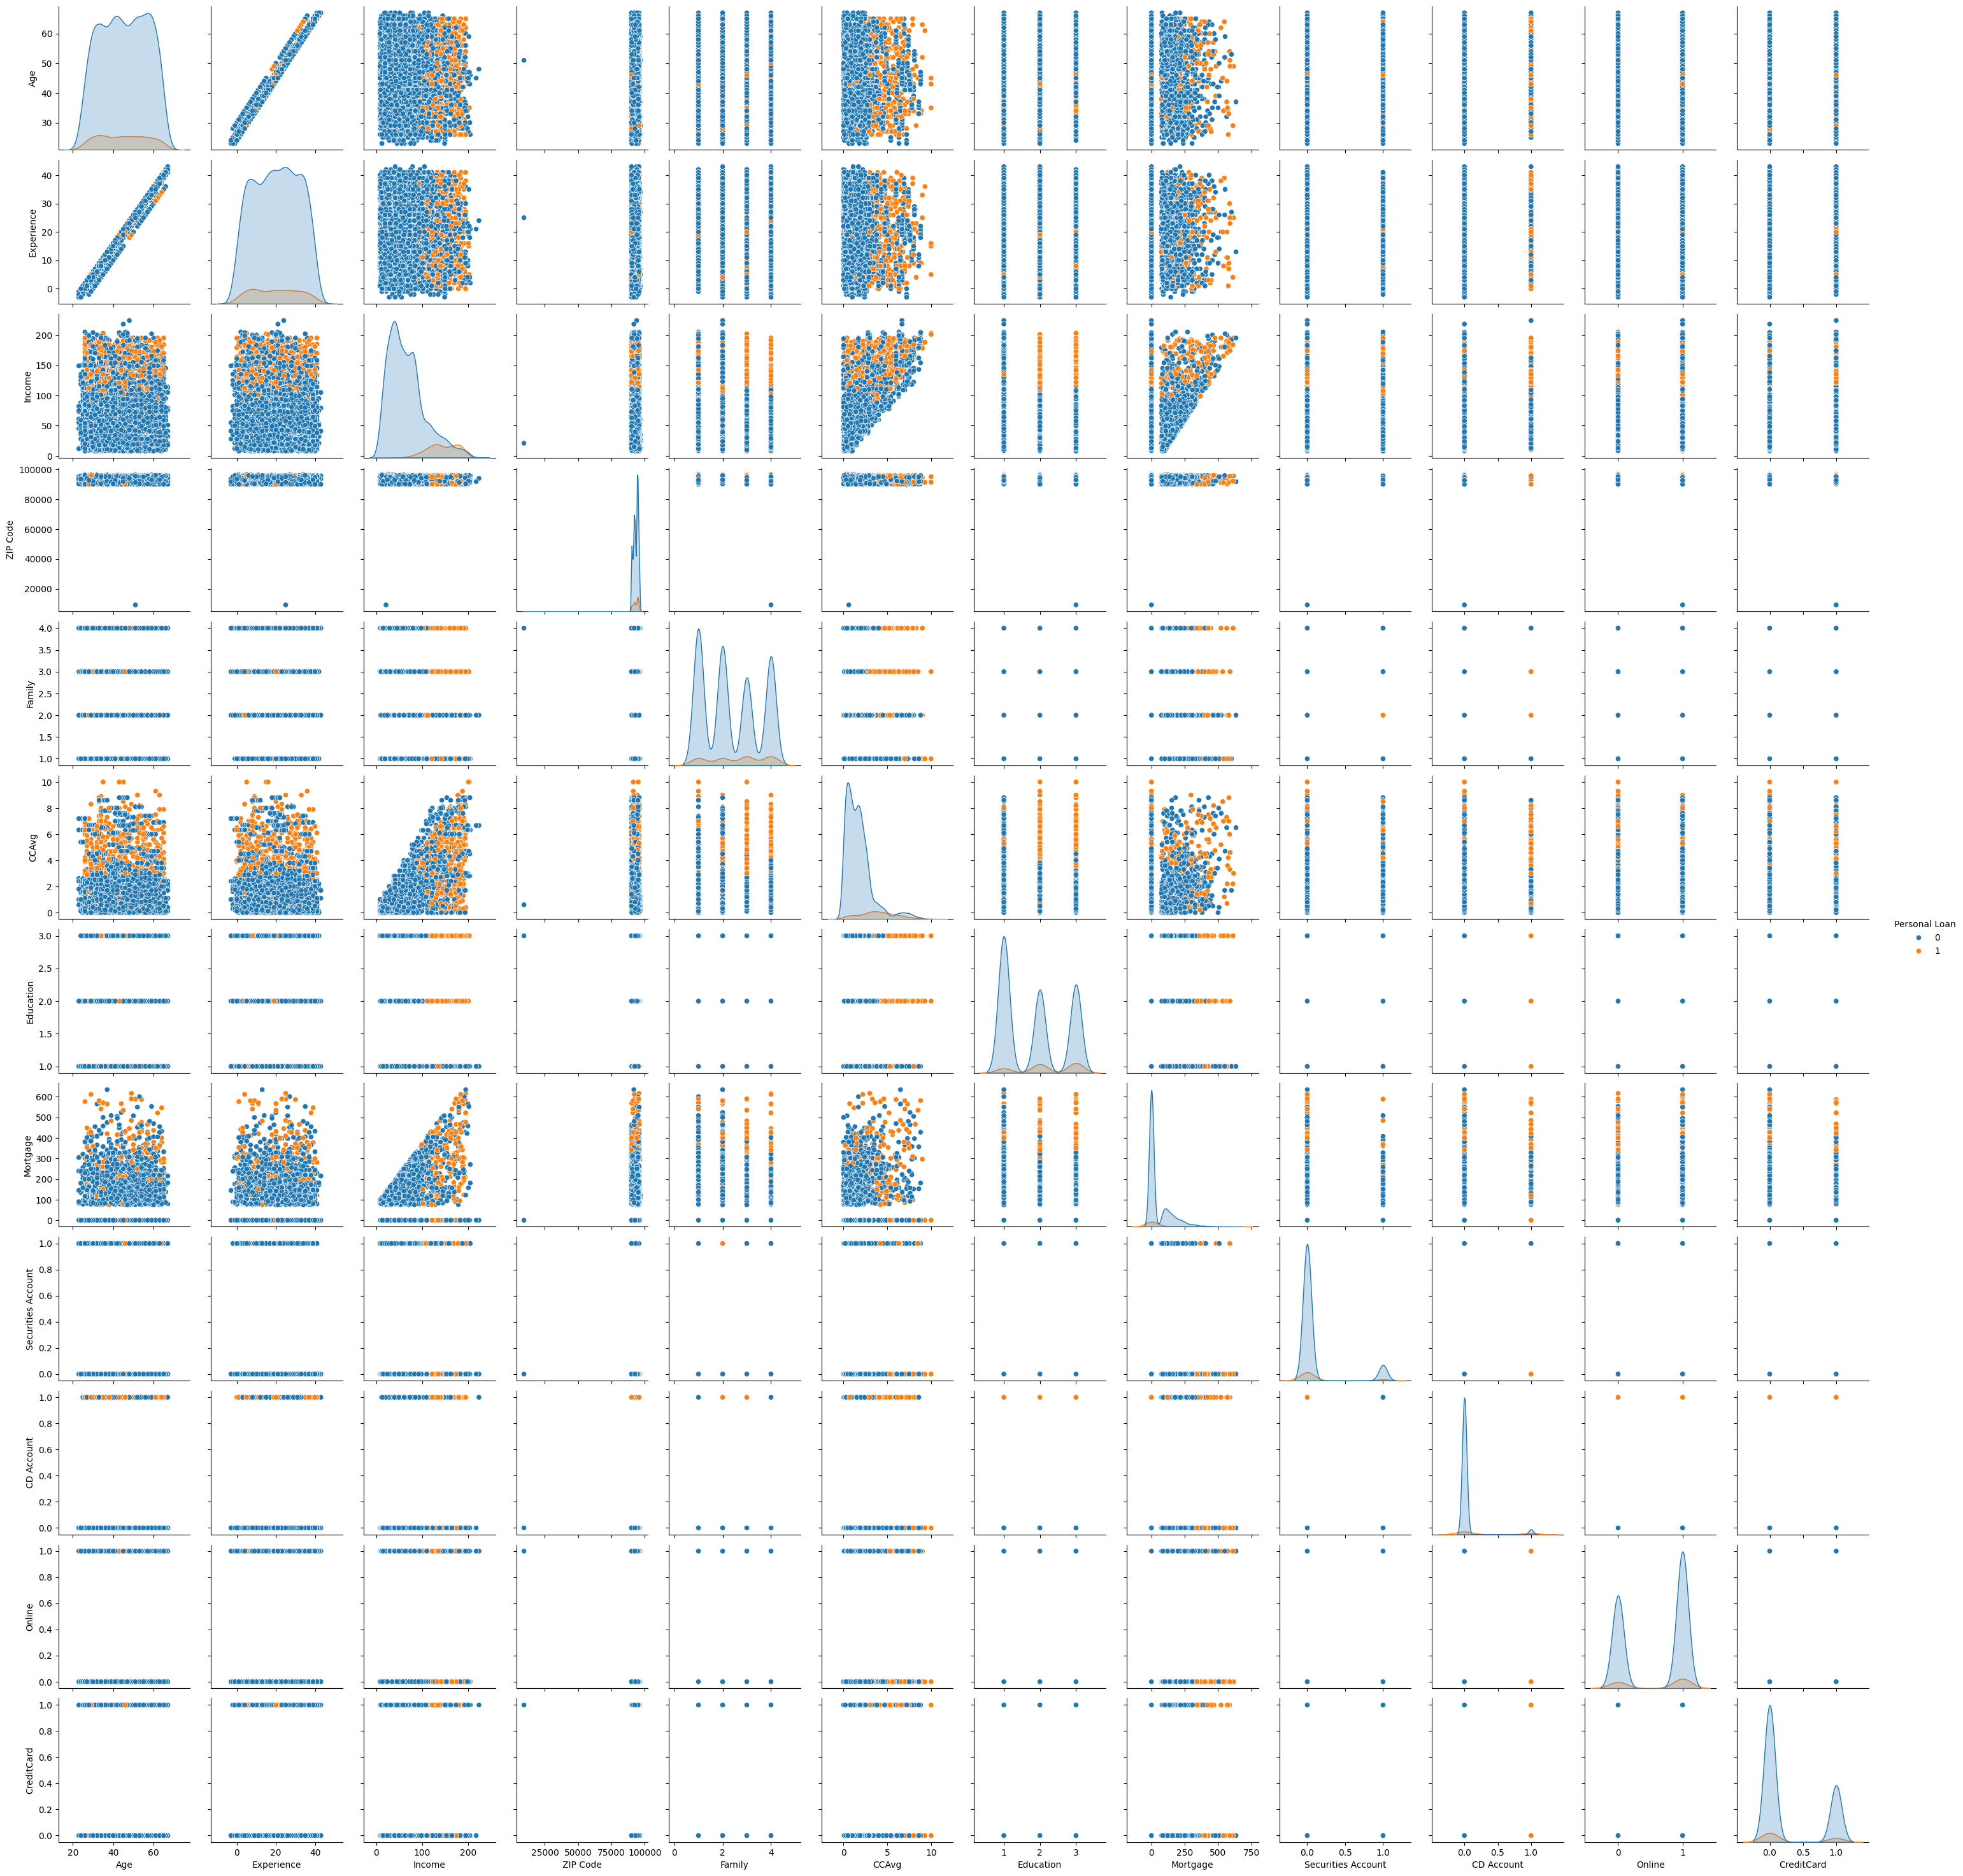

In [31]:
sns.pairplot(df_loan,
             hue = 'Personal Loan',
             vars = ['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
            'Education', 'Mortgage', 'Securities Account',
            'CD Account', 'Online', 'CreditCard'])

<Axes: xlabel='Personal Loan', ylabel='count'>

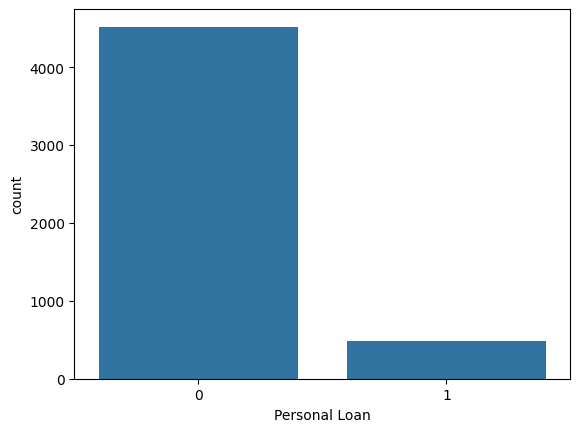

In [42]:
sns.countplot(x = df_loan['Personal Loan'])

<Axes: xlabel='Personal Loan', ylabel='count'>

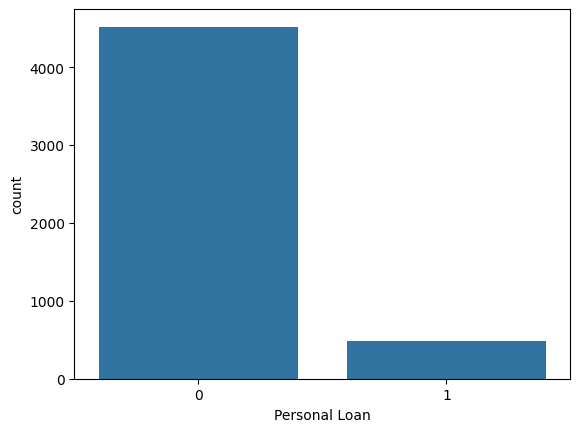

In [ ]:
sns.countplot(data = df_loan, x = 'Personal Loan')

có thể feed cho hàm countplot của seaborn 1 dataframe vào tham số data và x là cột cần vẽ biểu đồ đếm
hoặc là có thể feed trực tiếp series cần thực hiện vẽ biểu đồ đếm vào x hoặc y mà không cần tham số data

<Axes: >

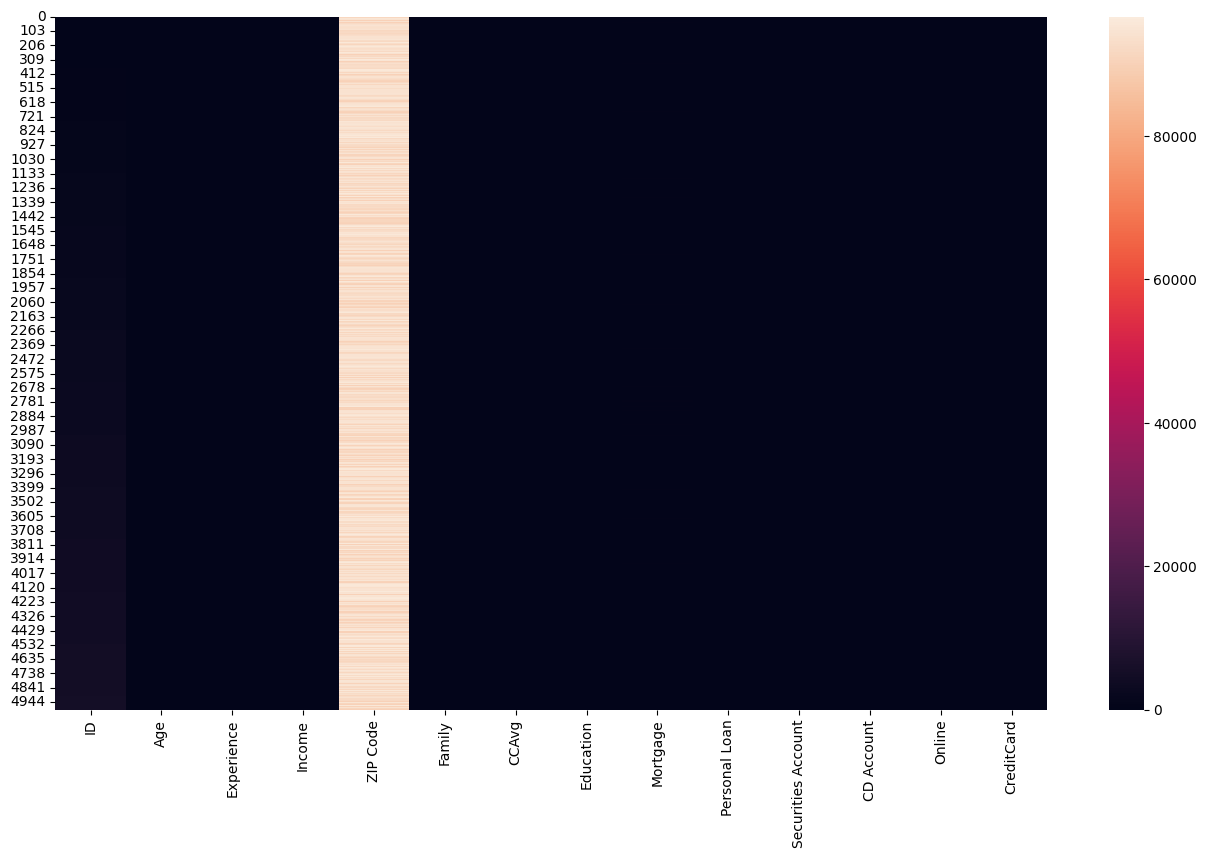

In [ ]:
plt.figure(figsize = (16,9))
sns.heatmap(df_loan)
# heatmap dùng chung 1 thang đo màu cho các giá trị trên mọi trường 
# giá trị càng lớn thì màu càng sáng

<Axes: >

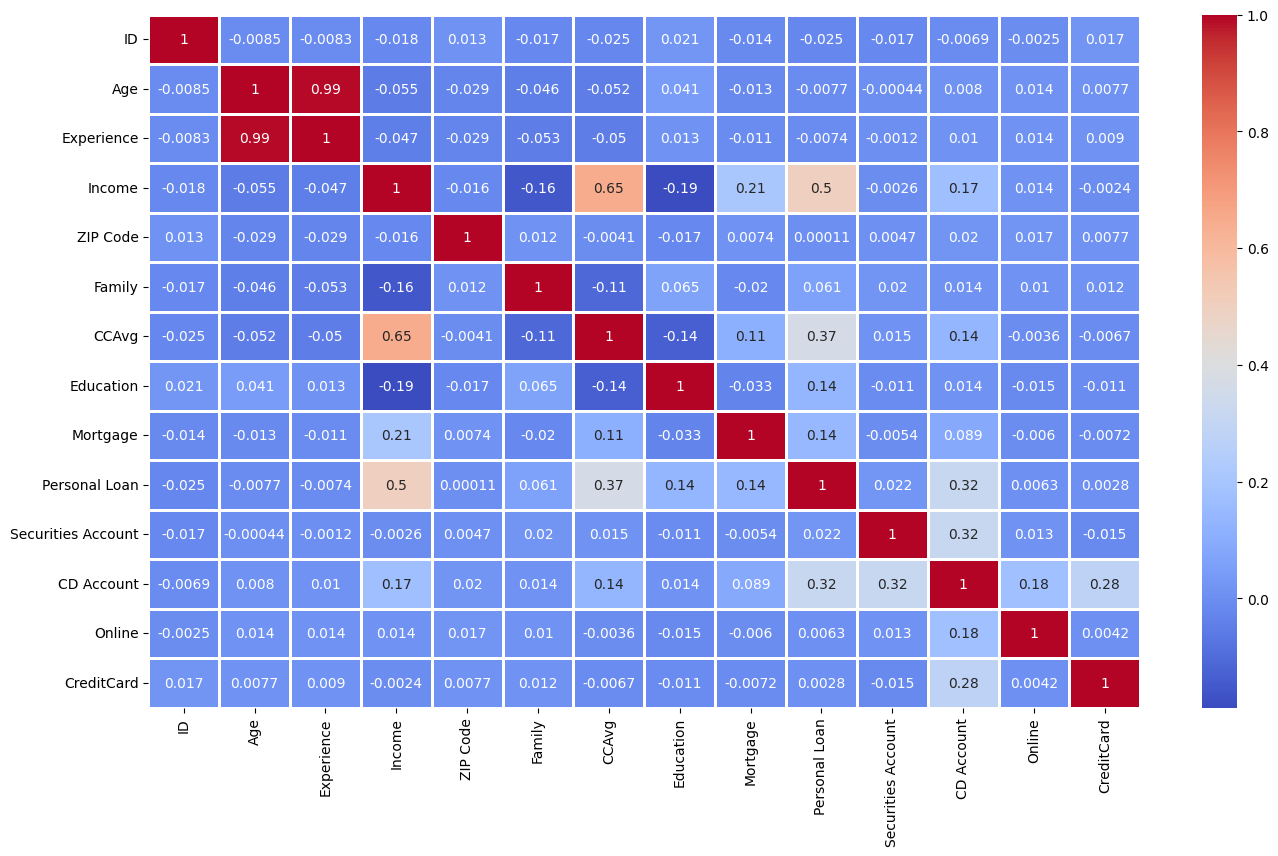

In [58]:
plt.figure(figsize = (16,9))
sns.heatmap(df_loan.corr(), annot=True, cmap='coolwarm', linewidths=2)
# annot = True để viết trực tiếp các con số vào ô
# cmap chọn màu, thường dùng coolwarm cho ma trận tương quan
# linewidths tạo đường thẳng nhỏ màu trắng giữa các ô

DATA PREPROCESSING

In [ ]:
X = df_loan.drop(columns = ['Personal Loan', 'ID'])
# có thể dùng axis = 1, giống với dùng tham số columns

In [68]:
X.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,1


In [71]:
print(X.max())
print(X.min())

Age                   0.492309
Experience            0.497726
Income                0.695490
ZIP Code              0.040054
Family                0.534533
CCAvg                 0.806206
Education             0.559500
Mortgage              0.911026
Securities Account    0.895600
CD Account            0.939600
Online                0.403200
CreditCard            0.706000
dtype: float64
Age                  -0.507691
Experience           -0.502274
Income               -0.304510
ZIP Code             -0.959946
Family               -0.465467
CCAvg                -0.193794
Education            -0.440500
Mortgage             -0.088974
Securities Account   -0.104400
CD Account           -0.060400
Online               -0.596800
CreditCard           -0.294000
dtype: float64


In [73]:
# cần chuẩn hóa các feature trong X về cùng 1 thang đo
# trong trường hợp này là trong khoảng 0 1
# để làm được vậy thì lấy X-X.min()/giá trị lớn nhất của chênh lệch
# có thể thực hiện các phép toán giữa 1 dataframe và series nếu chúng có cùng cột
X = (X - X.min())/(X.max() - X.min())

In [74]:
X.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,0.045455,0.086957,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,0.0
1,0.500000,0.478261,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,0.0
2,0.363636,0.391304,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,0.0
3,0.272727,0.260870,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,0.0
4,0.272727,0.239130,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,1.0


In [75]:
X.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,0.507691,0.502274,0.304510,0.959946,0.465467,0.193794,0.440500,0.088974,0.104400,0.06040,0.596800,0.294000
std,0.260526,0.249303,0.213119,0.024293,0.382554,0.174766,0.419935,0.160179,0.305809,0.23825,0.490589,0.455637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.272727,0.282609,0.143519,0.945732,0.000000,0.070000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,0.500000,0.500000,0.259259,0.963203,0.333333,0.150000,0.500000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,0.727273,0.717391,0.416667,0.976610,0.666667,0.250000,1.000000,0.159055,0.000000,0.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


<Axes: >

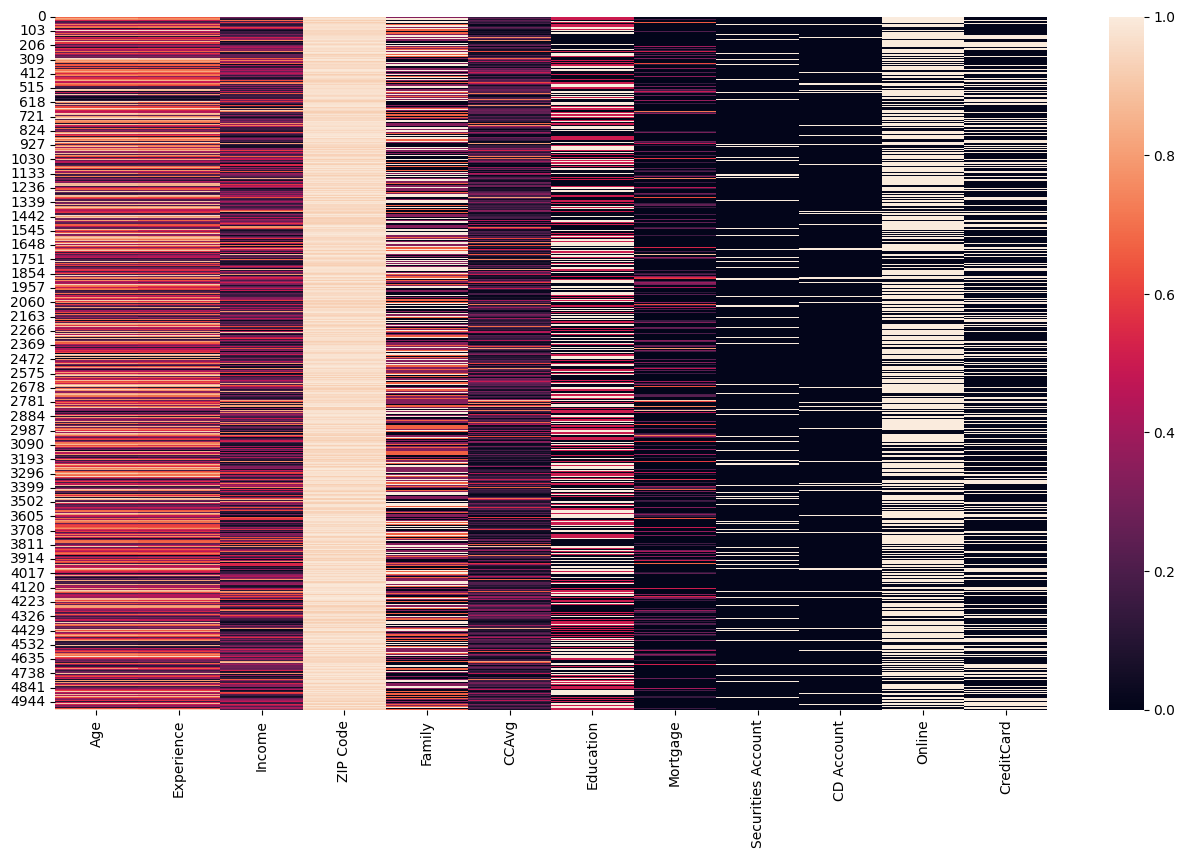

In [ ]:
plt.figure(figsize = (16,9))
sns.heatmap(X)

In [80]:
y = df_loan['Personal Loan']

In [83]:
from sklearn.model_selection import train_test_split
print(type(train_test_split(X, y, test_size = 0.2, random_state = 36)))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 36) 

<class 'list'>


In [86]:
X_train.shape, X_test.shape, y_test.shape, y_train.shape

((4000, 12), (1000, 12), (1000,), (4000,))

In [88]:
type(X_train), type(y_train)

(pandas.DataFrame, pandas.Series)